# CN 1 : Test of Data Class

In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])


from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
DataClass = STL_2D_FFT_Torch
WaveletOperatorClass = WaveletOperator2D_FFT_torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../c:\Users\Danie\Bureau\STL-Dev
Dataset dirctory used: .../c:\Users\Danie\Bureau\STL-Dev/data/test
Working on device: cpu


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

shape A = torch.Size([256, 256])


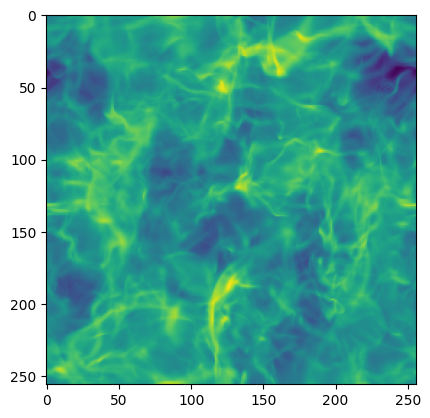

In [3]:
# Load some data and visualize it 
data_full = np.load(DATA_TEST_PATH + "/Turb_6.npy")[:2]

A_full = torch.from_numpy(data_full[0])
B_full = torch.from_numpy(data_full[1])

print("shape A = " + str(A_full.shape)) # (height, width)

plt.imshow(A_full, cmap="viridis")

In [4]:
# test initilization of STL_2D_FFT_Torch class
stl_A_full = DataClass(A_full, pbc = True)
Wop = stl_A_full.get_wavelet_op()

In [5]:
print("Attributes of stl_data_type_full:\n")
for attr, value in stl_A_full.__dict__.items():
    print(attr, "=", value)
    print()

Attributes of stl_data_type_full:

array = tensor([[20.1753, 20.1603, 20.1411,  ..., 20.1628, 20.1684, 20.1840],
        [20.1410, 20.1371, 20.1369,  ..., 20.1435, 20.1255, 20.1532],
        [20.1368, 20.1340, 20.1359,  ..., 20.1287, 20.1163, 20.1409],
        ...,
        [20.2385, 20.1890, 20.1470,  ..., 20.3206, 20.3140, 20.2882],
        [20.2286, 20.1976, 20.1556,  ..., 20.2404, 20.2510, 20.2498],
        [20.2046, 20.1793, 20.1461,  ..., 20.1950, 20.2152, 20.2231]],
       dtype=torch.float64)

pbc = True

dg = 0

N0 = torch.Size([256, 256])

conv_history = []

fourier_status = False

device = cpu

dtype = torch.float64



### Downgrade

In [6]:
A_dg0 = Wop.downsample(stl_A_full, dg_out = 0, inplace = False, target_fourier_status=False)
A_dg0.array = A_dg0.array.real
fft_A_dg0 = Wop.downsample(stl_A_full, dg_out = 0, inplace = False, target_fourier_status=True)

A_dg1 = Wop.downsample(stl_A_full, dg_out = 1, inplace = False, target_fourier_status=False)
A_dg1.array = A_dg1.array.real
fft_A_dg1 = Wop.downsample(stl_A_full, dg_out = 1, inplace = False, target_fourier_status=True)

A_dg2 = Wop.downsample(stl_A_full, dg_out = 2, inplace = False, target_fourier_status=False)
A_dg2.array = A_dg2.array.real
fft_A_dg2 = Wop.downsample(stl_A_full, dg_out = 2, inplace = False, target_fourier_status=True)

A_dg3 = Wop.downsample(stl_A_full, dg_out = 3, inplace = False, target_fourier_status=False)
A_dg3.array = A_dg3.array.real
fft_A_dg3 = Wop.downsample(stl_A_full, dg_out = 3, inplace = False, target_fourier_status=True)

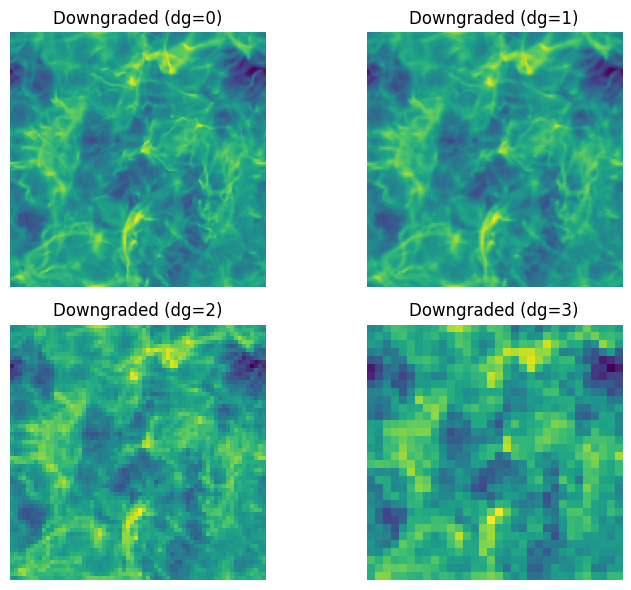

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

axs[0, 0].imshow(A_dg0.array)
axs[0, 0].set_title("Downgraded (dg=0)")
axs[0, 0].axis("off")

# Subplot 2
axs[0, 1].imshow(A_dg1.array)
axs[0, 1].set_title("Downgraded (dg=1)")
axs[0, 1].axis("off")

# Subplot 3
axs[1, 0].imshow(A_dg2.array)
axs[1, 0].set_title("Downgraded (dg=2)")
axs[1, 0].axis("off")

# Subplot 4
axs[1, 1].imshow(A_dg3.array)
axs[1, 1].set_title("Downgraded (dg=3)")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

### Mean

In [8]:
# The downsampling normalization is such that spatial mean is preserved in real space
print("Mean of A_dg0:", Wop.mean(A_dg0))
print("Mean of A_dg1:", Wop.mean(A_dg1))
print("Mean of A_dg2:", Wop.mean(A_dg2))
print("Mean of A_dg3:", Wop.mean(A_dg3))

Mean of A_dg0: tensor(20.3195, dtype=torch.float64)
Mean of A_dg1: tensor(20.3195, dtype=torch.float64)
Mean of A_dg2: tensor(20.3195, dtype=torch.float64)
Mean of A_dg3: tensor(20.3195, dtype=torch.float64)


In [9]:
# Implement fourier mean computation based on this downgrade function
print("Mean (in fourier space) of fft_A_dg0:", Wop.mean(fft_A_dg0).real)
print("Mean (in fourier space) of fft_A_dg1:", Wop.mean(fft_A_dg1).real)
print("Mean (in fourier space) of fft_A_dg2:", Wop.mean(fft_A_dg2).real)
print("Mean (in fourier space) of fft_A_dg3:", Wop.mean(fft_A_dg3).real)

Mean (in fourier space) of fft_A_dg0: tensor(20.3195, dtype=torch.float64)
Mean (in fourier space) of fft_A_dg1: tensor(20.3195, dtype=torch.float64)
Mean (in fourier space) of fft_A_dg2: tensor(20.3195, dtype=torch.float64)
Mean (in fourier space) of fft_A_dg3: tensor(20.3195, dtype=torch.float64)


### Square mean

In [10]:
# Let's check squared mean to be preserved in real space
# Let's compute, at all resolution, square mean for A convolved with a low pass filter in fourier space

In [11]:
# Low pass filter in fourier space (support is included in the lowest resolution) 
N = 32
u = np.arange(-N//2, N//2)
v = np.arange(-N//2, N//2)
U, V = np.meshgrid(u, v, indexing="ij")
R2 = U**2 + V**2

sigma_k = 4.0
H = np.exp(-R2 / (2 * sigma_k**2))
H = H / np.sum(H) # normalization to preserve mean in real space
H = torch.from_numpy(H)

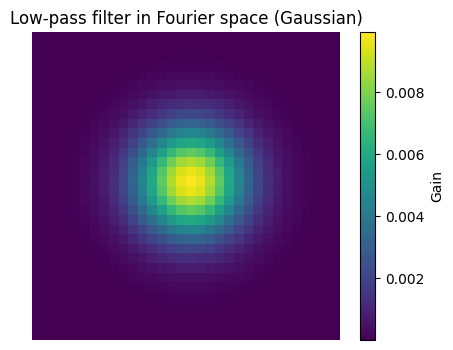

In [12]:
plt.figure(figsize=(5,4))
plt.imshow(H, origin="lower", cmap="viridis")
plt.colorbar(label="Gain")
plt.title("Low-pass filter in Fourier space (Gaussian)")
plt.axis("off")
plt.show()

In [13]:
A_filtered = F.conv2d(A_full.unsqueeze(0).unsqueeze(0).float(), H.unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0)
stl_A_filtered = DataClass(A_filtered, pbc=True)
Wop_filtered = stl_A_filtered.get_wavelet_op()

In [14]:
A_filtered_dg0 = Wop_filtered.downsample(stl_A_filtered, dg_out = 0, inplace = False, target_fourier_status=False)
A_filtered_dg0.array = A_filtered_dg0.array.real
fft_A_filtered_dg0 = Wop_filtered.downsample(stl_A_filtered, dg_out = 0, inplace = False, target_fourier_status=True)

A_filtered_dg1 = Wop_filtered.downsample(stl_A_filtered, dg_out = 1, inplace = False, target_fourier_status=False)
A_filtered_dg1.array = A_filtered_dg1.array.real    
fft_A_filtered_dg1 = Wop_filtered.downsample(stl_A_filtered, dg_out = 1, inplace = False, target_fourier_status=True)

A_filtered_dg2 = Wop_filtered.downsample(stl_A_filtered, dg_out = 2, inplace = False, target_fourier_status=False)
A_filtered_dg2.array = A_filtered_dg2.array.real
fft_A_filtered_dg2 = Wop_filtered.downsample(stl_A_filtered, dg_out = 2, inplace = False, target_fourier_status=True)

A_filtered_dg3 = Wop_filtered.downsample(stl_A_filtered, dg_out = 3, inplace = False, target_fourier_status=False)
A_filtered_dg3.array = A_filtered_dg3.array.real
fft_A_filtered_dg3 = Wop_filtered.downsample(stl_A_filtered, dg_out = 3, inplace = False, target_fourier_status=True)

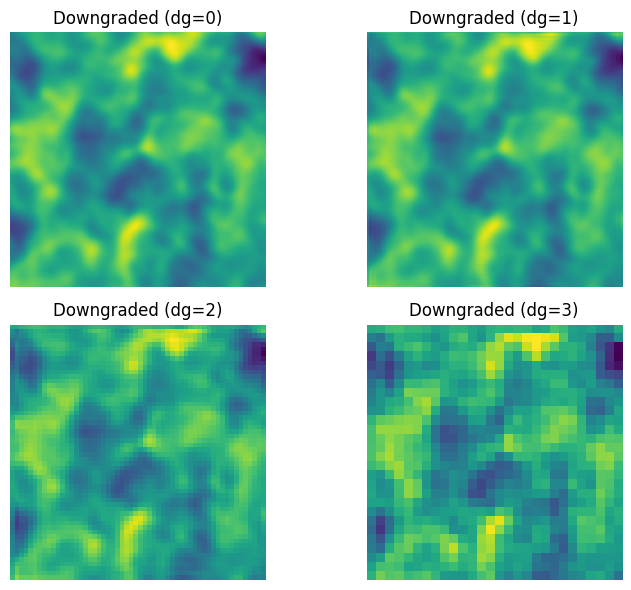

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

axs[0, 0].imshow(A_filtered_dg0.array)
axs[0, 0].set_title("Downgraded (dg=0)")
axs[0, 0].axis("off")

# Subplot 2
axs[0, 1].imshow(A_filtered_dg1.array)
axs[0, 1].set_title("Downgraded (dg=1)")
axs[0, 1].axis("off")

# Subplot 3
axs[1, 0].imshow(A_filtered_dg2.array)
axs[1, 0].set_title("Downgraded (dg=2)")
axs[1, 0].axis("off")

# Subplot 4
axs[1, 1].imshow(A_filtered_dg3.array)
axs[1, 1].set_title("Downgraded (dg=3)")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
# The downsampling normalization is such that spatial square mean is preserved in real space 
# (as soon as downgrading does not kill not null amplitudes frequency components, which is the case here since the low pass filter support is included in the lowest resolution)
print("Square mean of A_filtered_dg0:", Wop_filtered.square_mean(A_filtered_dg0, in_fourier=False))
print("Square mean of A_filtered_dg1:", Wop_filtered.square_mean(A_filtered_dg1, in_fourier=False))
print("Square mean of A_filtered_dg2:", Wop_filtered.square_mean(A_filtered_dg2, in_fourier=False))
print("Square mean of A_filtered_dg3:", Wop_filtered.square_mean(A_filtered_dg3, in_fourier=False))

Square mean of A_filtered_dg0: tensor(416.8755)
Square mean of A_filtered_dg1: tensor(416.8754)
Square mean of A_filtered_dg2: tensor(416.8752)
Square mean of A_filtered_dg3: tensor(416.8748)


In [17]:
# Implement fourier square mean computation based on this downgrade function
print("Square mean (in fourier space) of fft_A_filtered_dg0:", Wop_filtered.square_mean(fft_A_filtered_dg0, in_fourier=True).real)
print("Square mean (in fourier space) of fft_A_filtered_dg1:", Wop_filtered.square_mean(fft_A_filtered_dg1, in_fourier=True).real)
print("Square mean (in fourier space) of fft_A_filtered_dg2:", Wop_filtered.square_mean(fft_A_filtered_dg2, in_fourier=True).real)
print("Square mean (in fourier space) of fft_A_filtered_dg3:", Wop_filtered.square_mean(fft_A_filtered_dg3, in_fourier=True).real)

Square mean (in fourier space) of fft_A_filtered_dg0: tensor(416.8754)
Square mean (in fourier space) of fft_A_filtered_dg1: tensor(416.8753)
Square mean (in fourier space) of fft_A_filtered_dg2: tensor(416.8752)
Square mean (in fourier space) of fft_A_filtered_dg3: tensor(416.8748)


### Covariance

In [18]:
B_filtered = F.conv2d(B_full.unsqueeze(0).unsqueeze(0).float(), H.unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0)
stl_B_filtered = DataClass(B_filtered, pbc=True)

B_filtered_dg0 = Wop_filtered.downsample(stl_B_filtered, dg_out = 0, inplace = False, target_fourier_status=False)
B_filtered_dg0.array = B_filtered_dg0.array.real
fft_B_filtered_dg0 = Wop_filtered.downsample(stl_B_filtered, dg_out = 0, inplace = False, target_fourier_status=True)

B_filtered_dg1 = Wop_filtered.downsample(stl_B_filtered, dg_out = 1, inplace = False, target_fourier_status=False)
B_filtered_dg1.array = B_filtered_dg1.array.real    
fft_B_filtered_dg1 = Wop_filtered.downsample(stl_B_filtered, dg_out = 1, inplace = False, target_fourier_status=True)

B_filtered_dg2 = Wop_filtered.downsample(stl_B_filtered, dg_out = 2, inplace = False, target_fourier_status=False)
B_filtered_dg2.array = B_filtered_dg2.array.real
fft_B_filtered_dg2 = Wop_filtered.downsample(stl_B_filtered, dg_out = 2, inplace = False, target_fourier_status=True) 

B_filtered_dg3 = Wop_filtered.downsample(stl_B_filtered, dg_out = 3, inplace = False, target_fourier_status=False)
B_filtered_dg3.array = B_filtered_dg3.array.real 
fft_B_filtered_dg3 = Wop_filtered.downsample(stl_B_filtered, dg_out = 3, inplace = False, target_fourier_status=True)

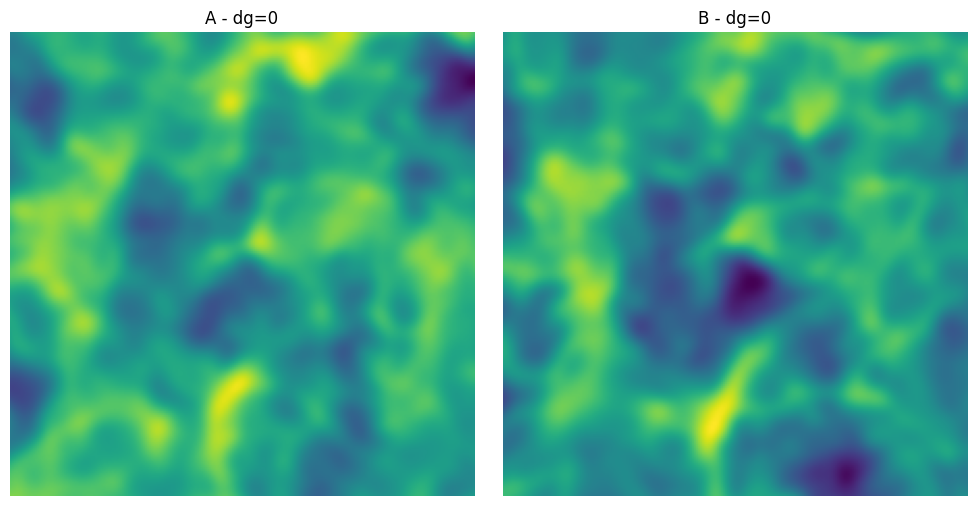

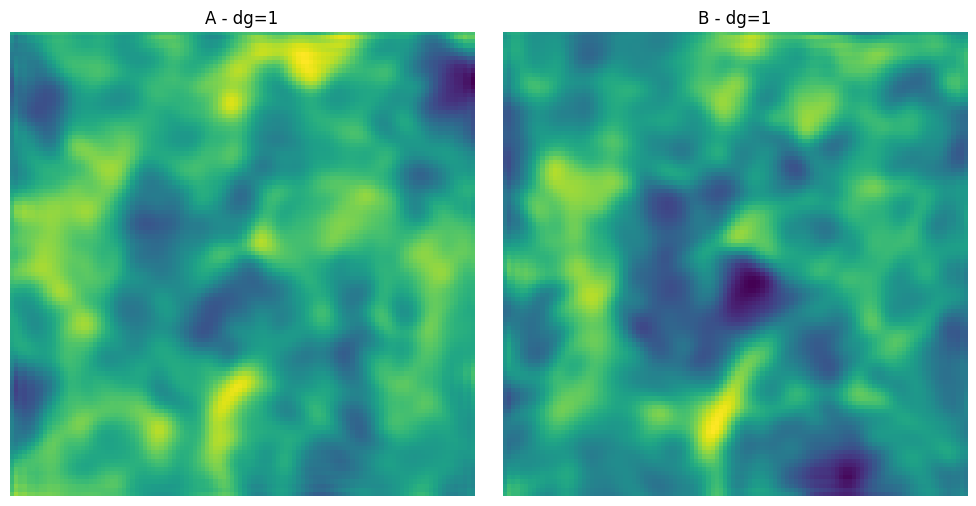

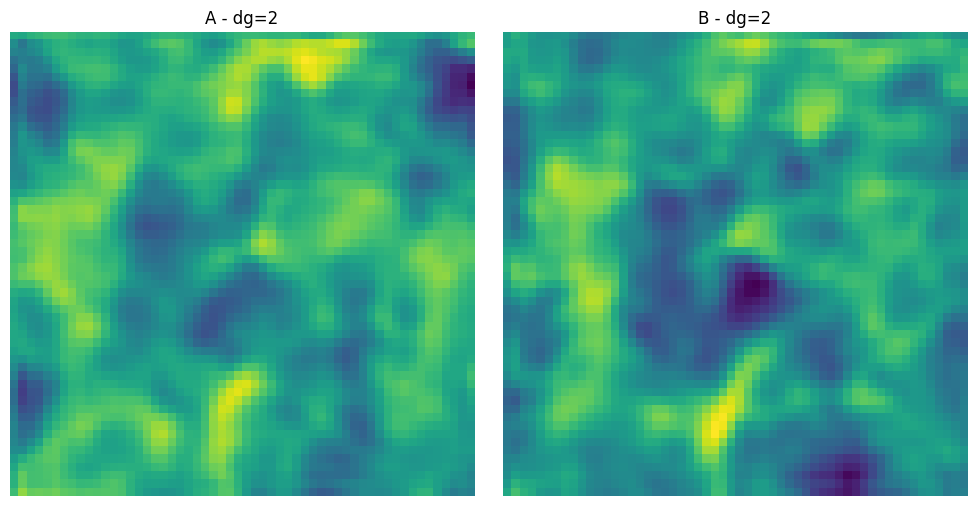

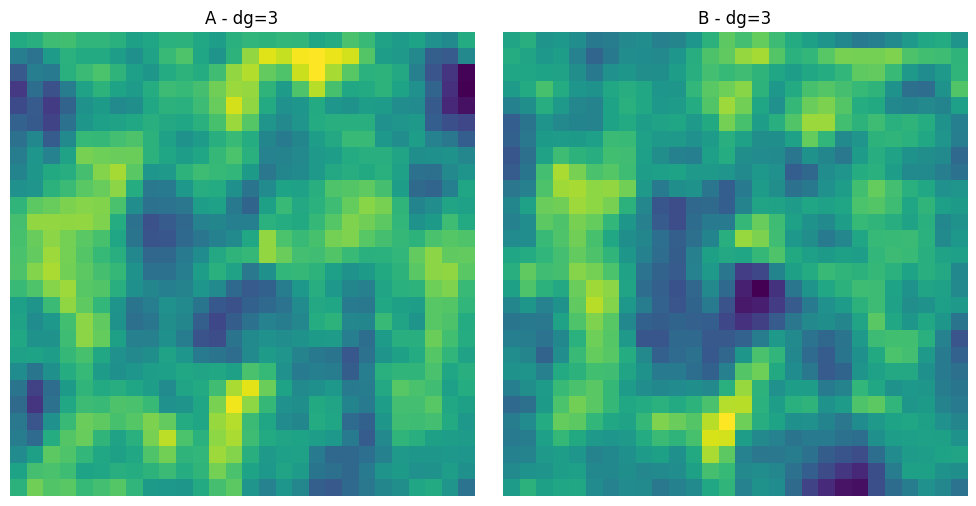

In [19]:
import matplotlib.pyplot as plt

images = [
    A_filtered_dg0.array, B_filtered_dg0.array,
    A_filtered_dg1.array, B_filtered_dg1.array,
    A_filtered_dg2.array, B_filtered_dg2.array,
    A_filtered_dg3.array, B_filtered_dg3.array
]

titles = [
    "A - dg=0", "B - dg=0",
    "A - dg=1", "B - dg=1",
    "A - dg=2", "B - dg=2",
    "A - dg=3", "B - dg=3"
]

for i in range(0, len(images), 2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))  
    for j in range(2):
        axs[j].imshow(images[i+j])
        axs[j].set_title(titles[i+j])
        axs[j].axis("off")
    plt.tight_layout()
    plt.show()

In [20]:
# The downsampling normalization is such that spatial square mean is preserved in real space 
# (as soon as downgrading does not kill not null amplitudes frequency components, which is the case here since the low pass filter support is included in the lowest resolution)
print("Covariance between A_filtered_dg0 and B_filtered_dg0:", Wop_filtered.cov(A_filtered_dg0, B_filtered_dg0))
print("Covariance between A_filtered_dg1 and B_filtered_dg1:", Wop_filtered.cov(A_filtered_dg1, B_filtered_dg1))
print("Covariance between A_filtered_dg2 and B_filtered_dg2:", Wop_filtered.cov(A_filtered_dg2, B_filtered_dg2))
print("Covariance between A_filtered_dg3 and B_filtered_dg3:", Wop_filtered.cov(A_filtered_dg3, B_filtered_dg3))

Covariance between A_filtered_dg0 and B_filtered_dg0: tensor(417.1367)
Covariance between A_filtered_dg1 and B_filtered_dg1: tensor(417.1367)
Covariance between A_filtered_dg2 and B_filtered_dg2: tensor(417.1366)
Covariance between A_filtered_dg3 and B_filtered_dg3: tensor(417.1366)


In [21]:
# The downsampling normalization is such that spatial square mean is preserved in real space 
# (as soon as downgrading does not kill not null amplitudes frequency components, which is the case here since the low pass filter support is included in the lowest resolution)
print("Covariance between fft_A_filtered_dg0 and fft_B_filtered_dg0:", Wop_filtered.cov(fft_A_filtered_dg0, fft_B_filtered_dg0).real)
print("Covariance between fft_A_filtered_dg1 and fft_B_filtered_dg1:", Wop_filtered.cov(fft_A_filtered_dg1, fft_B_filtered_dg1).real)
print("Covariance between fft_A_filtered_dg2 and fft_B_filtered_dg2:", Wop_filtered.cov(fft_A_filtered_dg2, fft_B_filtered_dg2).real)
print("Covariance between fft_A_filtered_dg3 and fft_B_filtered_dg3:", Wop_filtered.cov(fft_A_filtered_dg3, fft_B_filtered_dg3).real)

Covariance between fft_A_filtered_dg0 and fft_B_filtered_dg0: tensor(417.1366)
Covariance between fft_A_filtered_dg1 and fft_B_filtered_dg1: tensor(417.1366)
Covariance between fft_A_filtered_dg2 and fft_B_filtered_dg2: tensor(417.1365)
Covariance between fft_A_filtered_dg3 and fft_B_filtered_dg3: tensor(417.1365)
